In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.ensemble import GradientBoostingRegressor

In [2]:
df = pd.read_excel('delhi_kanpur_railway_dataset.xlsx')
df.head()

,Train_No,Train_Name,Source,Destination,Distance_km,Speed_kmph,Average_delay_min,dept_hour,arr_hour,duration_min,stops,departure_peak_flag,arrival_peak_flag,day_of_week,is_weekend,is_overnight_train,speed_category,train_type,priority
0,22436,New Delhi - Varanasi Vande Bharat Express,New Delhi,Kanpur Central,440,107,1,6,10,248,0,0,1,5,1,0,fast,Vande Bharat,Highest
1,22416,New Delhi - Varanasi Vande Bharat Express,New Delhi,Kanpur Central,440,107,2,15,19,248,0,0,1,5,1,0,fast,Vande Bharat,Highest
2,22426,Anand Vihar Terminal - Ayodhya Cantt. Vande Bh...,New Delhi,Kanpur Central,428,89,1,6,11,290,2,0,1,5,1,0,medium,Vande Bharat,Highest
3,12004,New Delhi - Lucknow Jn. Swarn Shatabdi Express,New Delhi,Kanpur Central,440,84,5,6,11,313,5,0,1,5,1,0,medium,Shatabdi,Very High
4,12034,New Delhi - Kanpur Central Shatabdi Express,New Delhi,Kanpur Central,440,85,8,15,20,310,3,0,1,5,1,0,medium,Shatabdi,Very High


In [3]:
df['dept_hour'] = df['dept_hour'].astype(int)
df = df.sort_values(by='dept_hour')

In [4]:
df['headway'] = df['dept_hour'].diff().fillna(0)
df.head()

,Train_No,Train_Name,Source,Destination,Distance_km,Speed_kmph,Average_delay_min,dept_hour,arr_hour,duration_min,stops,departure_peak_flag,arrival_peak_flag,day_of_week,is_weekend,is_overnight_train,speed_category,train_type,priority,headway
98,5306,Anand Vihar Terminal - Chhapra Special,New Delhi,Kanpur Central,428,63,10,0,7,410,1,0,1,5,1,0,medium,Express,Low,0.0
82,20434,Jammu Mail,New Delhi,Kanpur Central,432,85,21,4,9,305,2,0,1,5,1,0,medium,SuperFast,Medium,4.0
0,22436,New Delhi - Varanasi Vande Bharat Express,New Delhi,Kanpur Central,440,107,1,6,10,248,0,0,1,5,1,0,fast,Vande Bharat,Highest,2.0
2,22426,Anand Vihar Terminal - Ayodhya Cantt. Vande Bh...,New Delhi,Kanpur Central,428,89,1,6,11,290,2,0,1,5,1,0,medium,Vande Bharat,Highest,0.0
3,12004,New Delhi - Lucknow Jn. Swarn Shatabdi Express,New Delhi,Kanpur Central,440,84,5,6,11,313,5,0,1,5,1,0,medium,Shatabdi,Very High,0.0


## **Encode categorical variables**

In [5]:
# label encoding for categorical features

cat_cols = ['train_type', 'priority']

enc = LabelEncoder()

for col in cat_cols:
    df[col] = enc.fit_transform(df[col])
df.head()

,Train_No,Train_Name,Source,Destination,Distance_km,Speed_kmph,Average_delay_min,dept_hour,arr_hour,duration_min,stops,departure_peak_flag,arrival_peak_flag,day_of_week,is_weekend,is_overnight_train,speed_category,train_type,priority,headway
98,5306,Anand Vihar Terminal - Chhapra Special,New Delhi,Kanpur Central,428,63,10,0,7,410,1,0,1,5,1,0,medium,3,2,0.0
82,20434,Jammu Mail,New Delhi,Kanpur Central,432,85,21,4,9,305,2,0,1,5,1,0,medium,9,4,4.0
0,22436,New Delhi - Varanasi Vande Bharat Express,New Delhi,Kanpur Central,440,107,1,6,10,248,0,0,1,5,1,0,fast,11,1,2.0
2,22426,Anand Vihar Terminal - Ayodhya Cantt. Vande Bh...,New Delhi,Kanpur Central,428,89,1,6,11,290,2,0,1,5,1,0,medium,11,1,0.0
3,12004,New Delhi - Lucknow Jn. Swarn Shatabdi Express,New Delhi,Kanpur Central,440,84,5,6,11,313,5,0,1,5,1,0,medium,8,7,0.0


In [6]:
# aggregate data by hour, train-level data → hourly throughput data.

hourly_df = df.groupby('dept_hour').agg({
    'headway':'mean',
    'train_type':'count',
    'priority':'sum'
}).reset_index()

hourly_df.rename(columns={
    'train_type':'num_trains',
    'priority':'priority_trains'
}, inplace=True)

In [7]:
# define throughput as number of trains per hour

hourly_df['throughput'] = hourly_df['num_trains']
hourly_df.head()

,dept_hour,headway,num_trains,priority_trains,throughput
0,0,0.000000,1,2,1
1,4,4.000000,1,4,1
2,6,0.333333,6,17,6
3,7,0.200000,5,18,5
4,8,0.166667,6,24,6


## **Feature and Target selection**

In [8]:
# select features(x) and target variable(y)

features = [
    'dept_hour',
    'headway',
    'priority_trains'
]

X = hourly_df[features]
y = hourly_df['throughput']

## **Feature Scaling**

In [9]:
# standardize features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## **Cross_validation**

In [10]:
# define KFold cross-validation and hyperparameter grid for RandomizedSearchCV

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid = {
    'n_estimators':[100,200,300,400,500],
    'learning_rate':[0.01,0.03,0.05,0.1,0.15],
    'max_depth':[2,3,4,5],
    'min_samples_split':[2,4,6,8],
    'min_samples_leaf':[1,2,3,4],
    'subsample':[0.6,0.7,0.8,0.9,1.0]
}

In [11]:
# Gradient Boosting Regressor with Randomized Search

gbr = GradientBoostingRegressor(random_state=42)
random_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_grid,
    n_iter=50,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_scaled, y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,GradientBoost...ndom_state=42)
,param_distributions,"{'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,n_iter,50
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


## **Extracting best parameters**

In [12]:
# get the best model

best_model = random_search.best_estimator_

print("Best HyperParameters:")
print(random_search.best_params_)

Best HyperParameters:
{'subsample': 0.6, 'n_estimators': 500, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_depth': 4, 'learning_rate': 0.15}


In [13]:
# model evaluation 

predictions = best_model.predict(X_scaled)

mae = mean_absolute_error(y,predictions)

mse = mean_squared_error(y,predictions)

print("MAE:",mae)
print("MSE:",mse)

MAE: 0.17008337093021303
MSE: 0.08174025243314716


In [14]:
# predicting throughput 

hourly_df['predicted_throughput'] = best_model.predict(X_scaled)
hourly_df.head()

,dept_hour,headway,num_trains,priority_trains,throughput,predicted_throughput
0,0,0.000000,1,2,1,1.109637
1,4,4.000000,1,4,1,0.677827
2,6,0.333333,6,17,6,6.006774
3,7,0.200000,5,18,5,5.093518
4,8,0.166667,6,24,6,6.076326


In [15]:
# train passing through section per hour

hourly_trains = hourly_df[['dept_hour','predicted_throughput']]
hourly_trains

,dept_hour,predicted_throughput
0,0,1.109637
1,4,0.677827
2,6,6.006774
3,7,5.093518
4,8,6.076326
5,9,1.949168
6,11,1.002557
7,12,7.911538
8,13,2.993490
9,14,1.040142


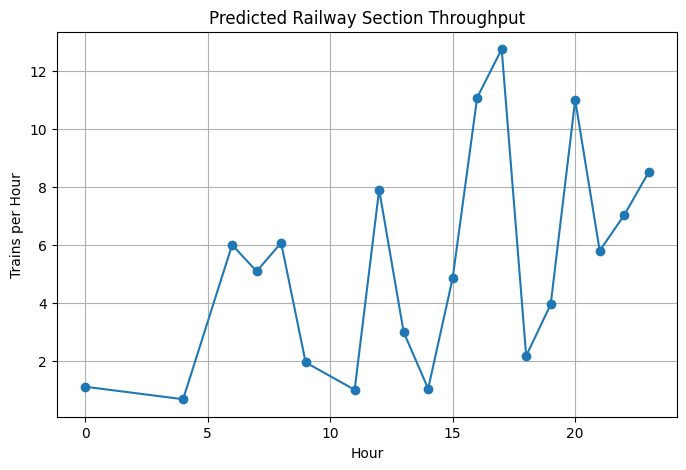

In [16]:
# plotting the predicted throughput over hours

plt.figure(figsize=(8,5))
plt.plot(hourly_df['dept_hour'],
         hourly_df['predicted_throughput'],
         marker='o')
plt.xlabel("Hour")
plt.ylabel("Trains per Hour")
plt.title("Predicted Railway Section Throughput")
plt.grid()
plt.show()

In [17]:
# Find the maximum predicted throughput
max_capacity = hourly_df['predicted_throughput'].max()
print("Maximum predicted throughput:",round(max_capacity,2),"trains/hour")

Maximum predicted throughput: 12.76 trains/hour
